1. You will be given a code cell that calculates the coefficients of a quadratic model (
) between two variables. All code in this cell will be correct. Then in the next code cell, a figure is generated with a scatter plot of the individual data and a line plot of the model prediction. However, the plot is obviously wrong. Make necessary modifications to generate a correct plot.

2. Read in a .csv file to create a DataFrame which contains weather data for Delhi, India in the year 2017. Using the ".plot()" method, generate a single line plot with (time vs. temperature) and (time vs. wind speed). The ".plot()" method is the one connected to a Pandas DataFrame, not the one in the matplotlib.pyplot library.

3. Read in a .csv file to create a DataFrame which contains conversion rates for Euros to U.S. dollars and British Pounds to U.S. dollars over time. Compute non-dimensional percentage growth values for each and plot together on a single plot. (You can use matplotlib.pyplot or the .plot() method connected to a DataFrame).

4. Continuing with the DataFrame of conversion rates, create a new column of Boolean type, which checks whether the conversion rate for one of the currencies was greater than a given value.

5. Continuing Problem 4, make a line plot of the conversion rate for this currency and highlight regions where the conversion rate is larger than a given value, using the function "plt.fill_between"

6. A code cell creates a DataFrame with the following columns. All columns are numerical:

time: A column containing evenly spaced values between 
 and 
. Denote them by 
sin: A column containing the sine function evaluated at those points. I.e. 
cos: A column containing the cosine function evaluated at those points. I.e. 
Using the ".diff()" method, create a new column called "d_sin_dt" with the following formula: 
.

From calculus, this should be close to 
, so plot (time vs. cos) and (time vs. d_sin_dt) together on a single figure to it.

In [1]:
import statsmodels.formula.api as smf
import pandas as pd 

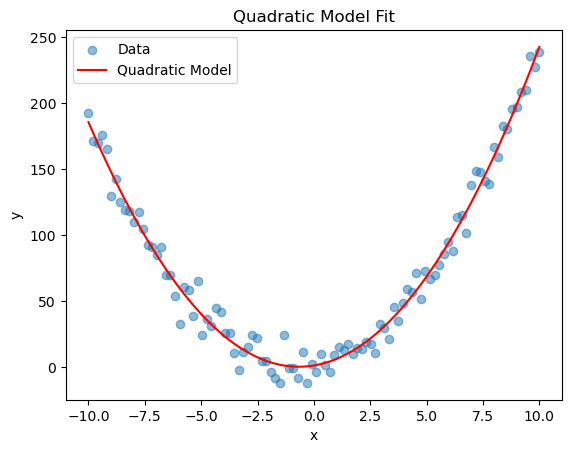

In [2]:
#Question 1
#1. You will be given a code cell that calculates the coefficients of a quadratic model () 
#between two variables. All code in this cell will be correct. 
#Then in the next code cell, a figure is generated with a scatter plot of the individual data 
#and a line plot of the model prediction. However, the plot is obviously wrong. 
# Make necessary modifications to generate a correct plot.

# your answer here
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Generate some example data
np.random.seed(0)
x = np.linspace(-10, 10, 100)
y = 2 * x**2 + 3 * x + 5 + np.random.normal(0, 10, size=x.shape)
data = pd.DataFrame({'x': x, 'y': y})   
# Fit a quadratic model
model = smf.ols('y ~ np.power(x, 2) + x', data=data).fit()
# Get model predictions
data['y_pred'] = model.predict(data)
# Plot the data and the model prediction
plt.scatter(data['x'], data['y'], label='Data', alpha=0.5)
plt.plot(data['x'], data['y_pred'], color='red', label='Quadratic Model')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Quadratic Model Fit')
plt.legend()
plt.show()



In [8]:
#Question 2
#Read in a .csv file to create a DataFrame which contains weather data for Delhi, India 
# in the year 2017. Using the ".plot()" method, generate a single line plot with (time vs. temperature) and (time vs. wind speed).
#  The ".plot()" method is the one connected to a Pandas DataFrame, not the one in the matplotlib.pyplot library.
# your answer here
df_weather = pd.read_csv('delhi_weather_2017.csv', parse_dates=['Date'])
df_weather.set_index('Date', inplace=True)
ax = df_weather['Temperature'].plot(label='Temperature', color='blue', figsize=(12, 6))
df_weather['Wind Speed'].plot(ax=ax, label='Wind Speed', color='orange')
ax.set_xlabel('Date')
ax.set_ylabel('Values')
ax.set_title('Delhi Weather in 2017: Temperature and Wind Speed')
ax.legend()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'delhi_weather_2017.csv'

In [6]:
#Question 3
# Read in a .csv file to create a DataFrame which contains conversion rates 
# for Euros to U.S. dollars and British Pounds to U.S. dollars over time. Compute non-dimensional 
# percentage growth values for each and plot together on a single plot. 
# (You can use matplotlib.pyplot or the .plot() method connected to a DataFrame).
# your answer here
df_currency = pd.read_csv('currency_conversion.csv', parse_dates=['Date'])
df_currency.set_index('Date', inplace=True)
df_currency['Euro_to_USD_pct_change'] = df_currency['Euro_to_USD'].pct_change() * 100
df_currency['GBP_to_USD_pct_change'] = df_currency['GBP_to_USD'].pct_change() * 100
plt.figure(figsize=(12, 6))
plt.plot(df_currency.index, df_currency['Euro_to_USD_pct_change'], label='Euro to USD % Change', color='blue')
plt.plot(df_currency.index, df_currency['GBP_to_USD_pct_change'], label='GBP to USD % Change', color='orange')
plt.xlabel('Date')
plt.ylabel('Percentage Change (%)')
plt.title('Currency Conversion Percentage Growth Over Time')
plt.legend()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'currency_conversion.csv'

In [5]:
#Question 4 
#Continuing with the DataFrame of conversion rates, create a new column of Boolean type, 
# which checks whether the conversion rate for one of the currencies was greater than a given value.
# your answer here
threshold_value = 1.2
df_currency['Euro_to_USD_above_threshold'] = df_currency['Euro_to_USD'] > threshold_value
display(df_currency.head())

NameError: name 'df_currency' is not defined

In [4]:
#Question 5 
# Continuing Problem 4, 
# make a line plot of the conversion rate for this currency and highlight 
# regions where the conversion rate is larger than a given value, using the function "plt.fill_between"
# your answer here
plt.figure(figsize=(12, 6))
plt.plot(df_currency.index, df_currency['Euro_to_USD'], label='Euro to USD Conversion Rate', color='blue')
plt.fill_between(df_currency.index, df_currency['Euro_to_USD'], where=df_currency['Euro_to_USD'] > threshold_value, 
                 color='red', alpha=0.3, label='Above Threshold')
plt.xlabel('Date')
plt.ylabel('Conversion Rate')
plt.title('Euro to USD Conversion Rate with Highlighted Regions')
plt.legend()
plt.show()

NameError: name 'df_currency' is not defined

<Figure size 1200x600 with 0 Axes>

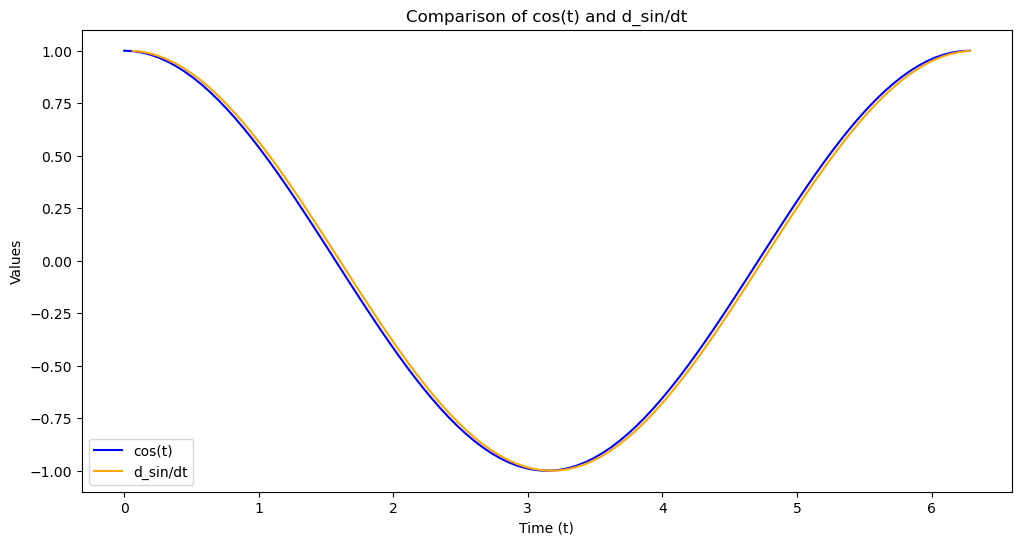

In [ ]:
#Question 6
#6. A code cell creates a DataFrame with the following columns. All columns are numerical:

#time: A column containing evenly spaced values between 0 and 2pi. Denote them by t0, t1, t2, ..., tn.
#sin: A column containing the sine function evaluated at those points. I.e. sin(t0), sin(t1), sin(t2), ..., sin(tn).
#cos: A column containing the cosine function evaluated at those points. I.e. cos(t0), cos(t1), cos(t2), ..., cos(tn).
#Using the ".diff()" method, create a new column called "d_sin_dt" with the following formula: sin(ti+1) - sin(ti) divided by ti+1 - ti..
#From calculus, this should be close to cos(tk), so plot (time vs. cos) and (time vs. d_sin_dt) together on a single figure to it.

import numpy as np  
num_points = 100
time = np.linspace(0, 2 * np.pi, num_points)
sin_values = np.sin(time)
cos_values = np.cos(time)   
df_trig = pd.DataFrame({'time': time, 'sin': sin_values, 'cos': cos_values})
df_trig['d_sin_dt'] = df_trig['sin'].diff() / df_trig['time'].diff()
plt.figure(figsize=(12, 6))
plt.plot(df_trig['time'], df_trig['cos'], label='cos(t)', color='blue')
plt.plot(df_trig['time'], df_trig['d_sin_dt'], label='d_sin/dt', color='orange')
plt.xlabel('Time (t)')
plt.ylabel('Values')
plt.title('Comparison of cos(t) and d_sin/dt')
plt.legend()
plt.show()